<a href="https://colab.research.google.com/github/Engr-Nauman/AI/blob/main/Decision_Tree_Regressor_CarMileage_04_07_2026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [374]:
import kagglehub
path = kagglehub.dataset_download("debajyotipodder/co2-emission-by-vehicles")

Using Colab cache for faster access to the 'co2-emission-by-vehicles' dataset.


In [375]:
path

'/kaggle/input/co2-emission-by-vehicles'

In [376]:
import numpy as np
import pandas as pd

In [377]:
df  = pd.read_csv(path + '/CO2 Emissions_Canada.csv')
df.head()

,Make,Model,Vehicle Class,Engine Size(L),Cylinders,Transmission,Fuel Type,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,ACURA,ILX,COMPACT,2.0,4,AS5,Z,9.9,6.7,8.5,33,196
1,ACURA,ILX,COMPACT,2.4,4,M6,Z,11.2,7.7,9.6,29,221
2,ACURA,ILX HYBRID,COMPACT,1.5,4,AV7,Z,6.0,5.8,5.9,48,136
3,ACURA,MDX 4WD,SUV - SMALL,3.5,6,AS6,Z,12.7,9.1,11.1,25,255
4,ACURA,RDX AWD,SUV - SMALL,3.5,6,AS6,Z,12.1,8.7,10.6,27,244


In [378]:
df_red = df.drop(columns = ['Make','Model','Vehicle Class','Transmission','Fuel Type'])
df_red.head()

,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
0,2.0,4,9.9,6.7,8.5,33,196
1,2.4,4,11.2,7.7,9.6,29,221
2,1.5,4,6.0,5.8,5.9,48,136
3,3.5,6,12.7,9.1,11.1,25,255
4,3.5,6,12.1,8.7,10.6,27,244


In [379]:
df_refined.isnull().sum()

,0
Engine Size(L),0
Cylinders,0
Fuel Consumption City (L/100 km),0
Fuel Consumption Hwy (L/100 km),0
Fuel Consumption Comb (L/100 km),0
Fuel Consumption Comb (mpg),0
CO2 Emissions(g/km),0


In [380]:
df_refined.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 7 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Engine Size(L)                    7385 non-null   float64
 1   Cylinders                         7385 non-null   int64  
 2   Fuel Consumption City (L/100 km)  7385 non-null   float64
 3   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 4   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 5   Fuel Consumption Comb (mpg)       7385 non-null   int64  
 6   CO2 Emissions(g/km)               7385 non-null   int64  
dtypes: float64(4), int64(3)
memory usage: 404.0 KB


In [381]:
#Luckily this dataset doesn't have null values
## Let's start training decision tree on the given data

## Input features are
### Engine Size (L)
### Cylinders
### Fuel Consumption City (L/100 km)
###  Fuel Consumption Hwy (L/100 km)
###  Fuel Consumption Comb (L/100 km)
###  Fuel Consumption Comb (mpg)

## Out of the model is
###   CO2 Emissions(g/km)

In [382]:
from sklearn.tree import DecisionTreeRegressor, export_text
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

In [383]:
X_train, X_test, y_train, y_test = train_test_split(df_red.drop(columns = ['CO2 Emissions(g/km)']), df_red['CO2 Emissions(g/km)'], test_size=0.3, random_state=42)

Here we set the depth to 4, the nodes for treee

In [384]:
regressor = DecisionTreeRegressor(max_depth=22, random_state=42)

Training the model using fit method

In [385]:
regressor.fit(X_train, y_train)

DecisionTreeRegressor(max_depth=22, random_state=42)

In [386]:
y_predict = regressor.predict(X_test)

In [387]:
i = 1314
y = regressor.predict(X_test.iloc[[i]])
print(y-y_test.iloc[i])

[8.]


In [388]:
# Now let's check the acquracy of the model using
# mean squared error
mse = mean_squared_error(y_test, y_predict)
print(f"Mean Squared Error: {mse:.4f}")

Mean Squared Error: 126.0175


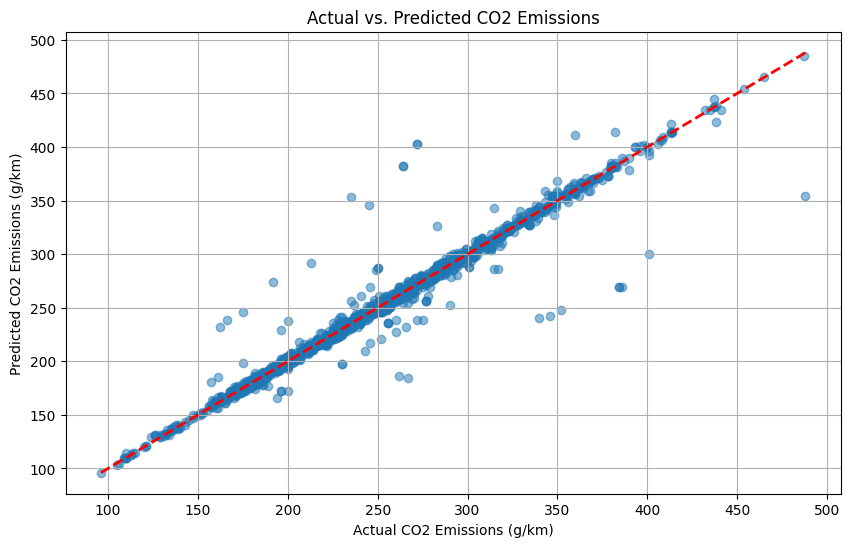

In [389]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_predict, alpha=0.5)
plt.xlabel("Actual CO2 Emissions (g/km)")
plt.ylabel("Predicted CO2 Emissions (g/km)")
plt.title("Actual vs. Predicted CO2 Emissions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # Line for perfect prediction
plt.grid(True)
plt.show()

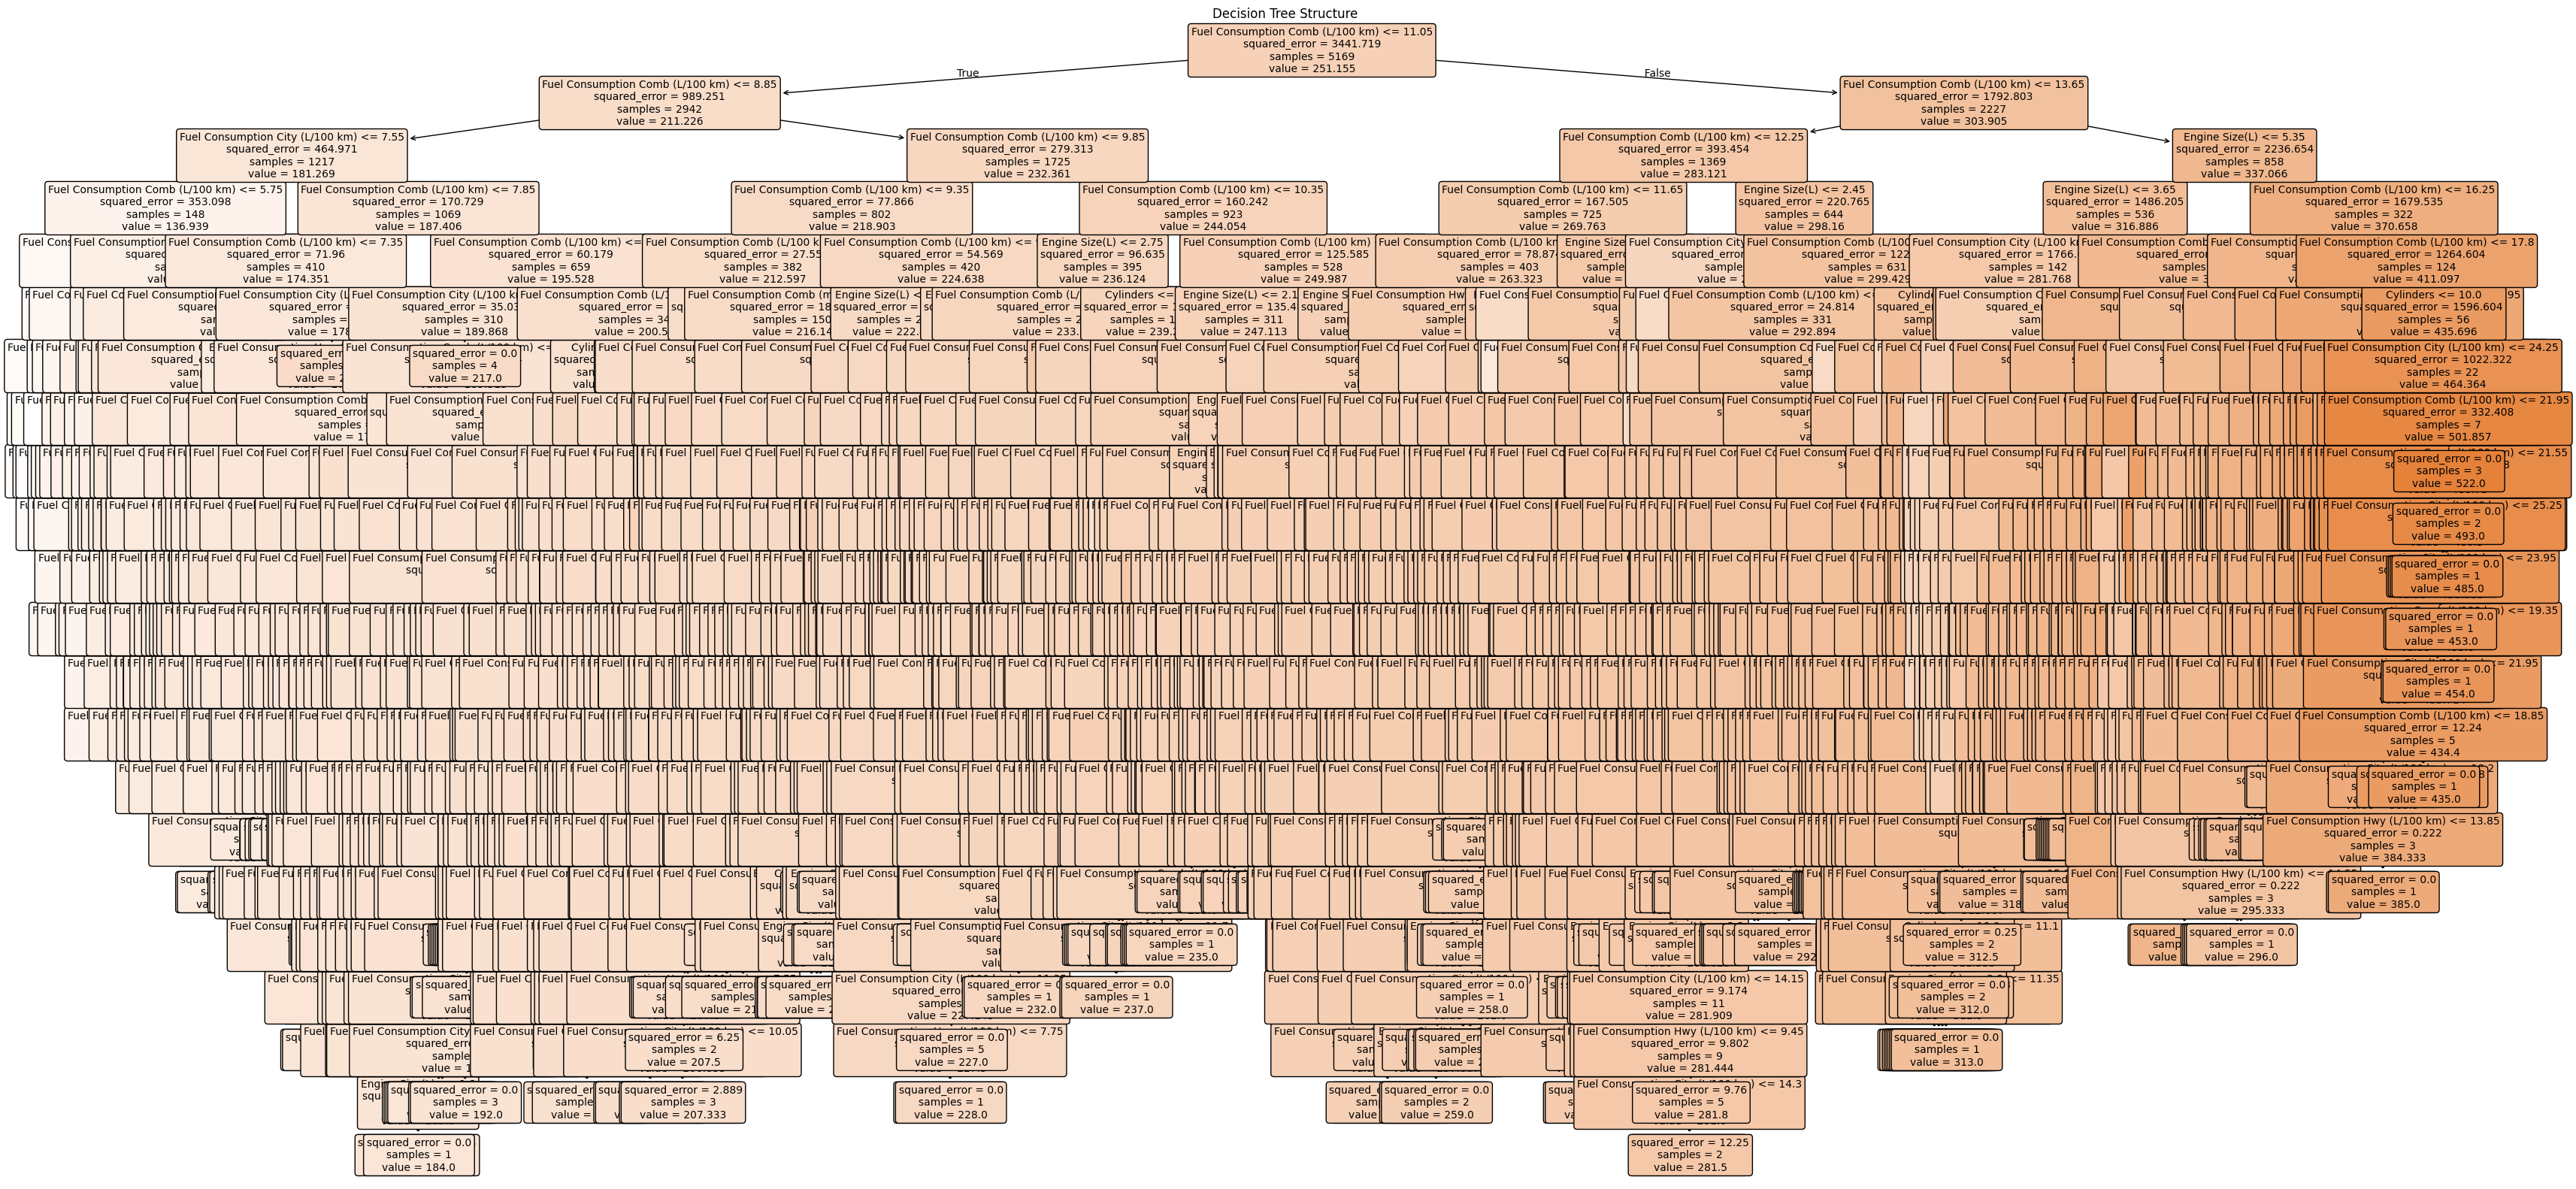

In [390]:
from sklearn.tree import plot_tree

plt.figure(figsize=(40, 20))
plot_tree(
    regressor,
    feature_names=X_train.columns.tolist(),
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree Structure")
plt.show()